![NVIDIA Logo](images/nvidia.png)

# Custom Stage - Update Message

In this notebook you'll create your first set of custom stages that actually perform work on incoming messages.

---

## Objectives

By the time you complete this notebook you will be able to:

- Create custom stages that perform actual work on the data they are processing.
- Process data in a thread-safe way, and without making full copies of it.
- Parameterize custom stages to enable greater flexibility and reuse.

---

## Imports

The following imports are used in this notebook. We will look at each of them individually as they are used in code.

In [1]:
import typing
import logging

from IPython.display import Image
import cudf

from morpheus.config import Config
from morpheus.pipeline import LinearPipeline

from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage

from morpheus.messages import MessageMeta

from morpheus.pipeline.execution_mode_mixins import GpuAndCpuMixin
from morpheus.pipeline.pass_thru_type_mixin import PassThruTypeMixin
from morpheus.pipeline.single_port_stage import SinglePortStage

from morpheus.cli.register_stage import register_stage

from morpheus.utils.logger import configure_logging, reset_logging

import mrc
from mrc.core import operators as ops

---

## Perform Work Inside Custom Stage

Up until now we have only explored no-op passthrough stages in the spirit of keeping things simple. Of course in reality we want to write custom stages to perform work on the data in our pipeline.

Below is the definition of an `UpperCaseStage` which currently will modify its incoming dataframe by uppercasing the text found in the incoming data's `"status"` column.

In [28]:
@register_stage("uppercase")
class UpperCaseStage(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):

    @property
    def name(self) -> str:
        return "uppercase"

    def accepted_types(self) -> tuple:
        return (MessageMeta, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: MessageMeta) -> MessageMeta:
        df = message.copy_dataframe()
        # df["status"] = df["status"].str.upper()
        df["user"] = df["user"].str.upper()
        return MessageMeta(df)

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

You'll notice the only change we've made from the custom passthrough stage created in the previous notebook is the alteration of its `on_data` where we are performing the uppercasing operation.

---

## Use Custom Stage With Processing

Let's construct a pipeline utilizing our custom `UpperCaseStage`

In [29]:
input_file = 'data/simple_user_log.jsonlines'

It's worth noticing that the data's `"status"` column currently contains lowercased entries.

In [30]:
cudf.read_json(input_file, lines=True)

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
2,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
4,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
6,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
8,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked


In [31]:
config = Config()

In [32]:
pipeline = LinearPipeline(config)

pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))
pipeline.add_stage(UpperCaseStage(config))
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

In [33]:
pipeline.build()

In [34]:
viz_file = './pipeline_visualizations/uppercase.png'
pipeline.visualize(viz_file)

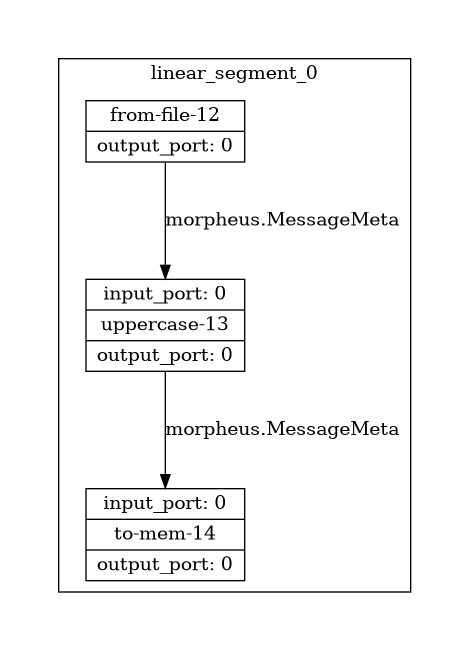

In [35]:
Image(filename=viz_file)

In [36]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

W20250922 08:38:12.258042 140126692644672 logging.cpp:67] MRC logger already initialized


====Starting Pipeline====
====Pipeline Started====
====Building Segment: linear_segment_0====
Added source: <from-file-12; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <uppercase-13; UpperCaseStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
Added stage: <to-mem-14; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
====Building Segment Complete!====
====Pipeline Complete====


In [37]:
await pipeline.run_async()

Here we see the data has been processed as expected.

In [38]:
messages = in_mem_sink.get_messages()
messages[0].df

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,USER123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,USER123,192.168.1.20,150.55,failure,Invalid credentials
2,2025-02-01T10:18:10Z,USER456,10.0.0.5,180.60,success,<NA>
3,2025-02-01T10:19:25Z,USER789,192.168.1.30,215.25,failure,Timeout
4,2025-02-01T10:20:00Z,USER456,10.0.0.6,120.10,success,<NA>
5,2025-02-01T10:22:30Z,USER123,192.168.1.40,175.35,failure,Access denied
6,2025-02-01T10:23:45Z,USER321,192.168.1.50,205.50,success,<NA>
7,2025-02-01T10:25:05Z,USER864,192.168.1.60,190.15,failure,Invalid session
8,2025-02-01T10:26:20Z,USER123,192.168.1.70,210.80,success,<NA>
9,2025-02-01T10:27:40Z,USER456,10.0.0.7,160.95,failure,Account locked


---

## Mutable Dataframes

For any number of reasons, not the least of which is performance, we may not always want to be making copies of a message's underlying dataframe. However, we need to take care that in more complicated pipelines, where data may be getting processed simultaneously by multiple stages (or individual nodes within stages), that we don't end up in race condition scenarios.

In order to avoid making a full copy of incoming data and also to avoid race conditions, we can use `MessageMeta`'s `mutable_dataframe` context creator as shown below:

```python
def on_data(self, message: MessageMeta) -> MessageMeta:
    with message.mutable_dataframe() as df:
        df["status"] = df["status"].str.upper()

    return message
```

In the above snippet, we do not make a copy of `message`'s underlying dataframe and within the context of the `with` statement, we can modify `df` in a thread-safe manner. The `mutable_dataframe` uses a mutex internally to protect the shared dataframe resource. This mutex ensures that only one thread can access and modify the dataframe at a time, preventing race conditions that could occur if multiple processing units in the pipeline attempted to modify the dataframe simultaneously.

---

## Exercise: Re-Create the Pipeline to Perform Thread-Safe Non-Copying Data Updates

Build a new pipeline to again perform uppercasing on the `"status"` column, but this time do so using the `mutable_dataframe` paradigm we just discussed.

Feel free to check out the *Solution* below if you get stuck.

### Your Work Here

In [23]:
@register_stage("status-upper")
class StatusUpper(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    @property
    def name(self) -> str:
        return "status-upper"
    def accepted_types(self) -> tuple:
        return (MessageMeta, )
    def supports_cpp_node(self) -> bool:
        return False
    def on_map(self, message: MessageMeta) -> MessageMeta:
        with message.mutable_dataframe() as df:
            df["status"] = df['status'].str.upper()
        return MessageMeta(df)
    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_map))
        builder.make_edge(input_node, node)
        return node

In [24]:
config = Config()
pipeline = LinearPipeline(config)
pipeline.set_source(FileSourceStage(config, iterative=False, filename=input_file))
pipeline.add_stage(StatusUpper(config))
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))
pipeline.build()

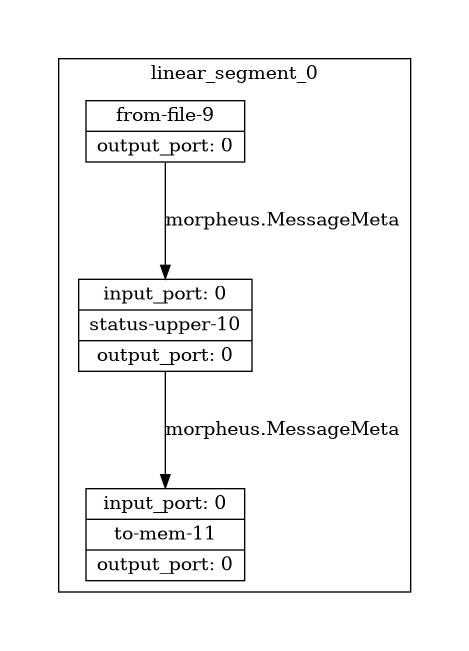

In [25]:
viz_file = "./pipeline_visualizations/exe-23.png"
pipeline.visualize(viz_file)
Image(viz_file)

In [26]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

W20250922 08:35:01.323394 140126692644672 logging.cpp:67] MRC logger already initialized


====Starting Pipeline====
====Pipeline Started====
====Building Segment: linear_segment_0====
Added source: <from-file-9; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <status-upper-10; StatusUpper()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
Added stage: <to-mem-11; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
====Building Segment Complete!====
====Pipeline Complete====
====Pipeline Pre-build====
====Pre-Building Segment: linear_segment_0====
====Pre-Building Segment Complete!====
====Pipeline Pre-build Complete!====
====Registering Pipeline====
====Building Pipeline====
====Building Pipeline Complete!====
====Registering Pipeline Complete!====


In [27]:
await pipeline.run_async()

### Solution

In [ ]:
@register_stage("uppercase")
class UpperCaseStage(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):

    @property
    def name(self) -> str:
        return "uppercase"

    def accepted_types(self) -> tuple:
        return (MessageMeta, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: MessageMeta) -> MessageMeta:
        with message.mutable_dataframe() as df:
            df["status"] = df["status"].str.upper()

        return message

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

In [ ]:
config = Config()

In [ ]:
pipeline = LinearPipeline(config)

pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))
pipeline.add_stage(UpperCaseStage(config))
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

In [ ]:
pipeline.build()

In [ ]:
viz_file = './pipeline_visualizations/uppercase.png'
pipeline.visualize(viz_file)

In [ ]:
Image(filename=viz_file)

In [ ]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

In [ ]:
await pipeline.run_async()

Here we see the data has been processed as expected.

In [ ]:
messages = in_mem_sink.get_messages()
messages[0].df

---

## Parameterize Column

Since we are just working with Python classes in our stage definitions, there's no reason why we can't also further parameterize our custom stages.

Here's an updated version of our custom stage, but we've explicitly included its `__init__` method to set a `column_name` parameter.

In [ ]:
@register_stage("uppercase")
class UpperCaseStage(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    def __init__(self, config: Config, column_name: str):
        super().__init__(config)
        self._column_name = column_name

    @property
    def name(self) -> str:
        return "uppercase"

    def accepted_types(self) -> tuple:
        return (MessageMeta, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: MessageMeta) -> MessageMeta:
        with message.mutable_dataframe() as df:
            df[self._column_name] = df[self._column_name].str.upper()

        return message

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

Now when we create the custom stage we can pass in the column that we would wish to perform the uppercase operation on.

In [ ]:
config = Config()
pipeline = LinearPipeline(config)

pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))

# Here we specify to perform the upper case operation on the `"user"` column.
pipeline.add_stage(UpperCaseStage(config, "user"))

in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

In [ ]:
pipeline.build()

In [ ]:
viz_file = './pipeline_visualizations/uppercase.png'
pipeline.visualize(viz_file)

In [ ]:
Image(filename=viz_file)

In [ ]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

In [ ]:
await pipeline.run_async()

Here we see the data has been processed as expected.

In [ ]:
messages = in_mem_sink.get_messages()
messages[0].get_data()